In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import gsw

In [3]:
# read in model data for each station
station_names = ["SAR003", "PSS019", "SKG003","HCB004", "HCB003", "ADM003", "CMB003", "GOR001", "CSE001", "EAP001", "SIN001", "PSB003"]

data_lo = {}
data_ssc = {}

for station in station_names:
    filename_lo = f"{station}_2014.01.01_2014.12.31.nc"
    filename_ssc = f"{station}_2014.01.01_2014.12.31_ssc.nc"
    filepath_lo = "stations/" + filename_lo
    filepath_ssc = "stations/" + filename_ssc

    data_lo[station] = xr.open_dataset(filepath_lo)
    data_ssc[station] = xr.open_dataset(filepath_ssc)

In [4]:
# read in observational dataset (contains lat and lon for each station)
obs_data = pd.read_pickle("./combined_bottle_2014_cas7_t1_x11ab_ssc.pkl")
obs = obs_data['obs']
station_coords = (
    obs.groupby("name")[["lat", "lon"]]
    .first()
    .to_dict(orient="index")
)

In [11]:
print(obs.columns.tolist())

['cid', 'lon', 'lat', 'time', 'z', 'SA', 'CT', 'DO', 'NO3', 'Chl', 'name', 'cruise', 'source', 'NH4', 'PO4 (uM)', 'SiO4 (uM)', 'NO2 (uM)', 'TA', 'DIC']


In [5]:
station = "SAR003"

print(data_lo[station].data_vars)
#print(data_ssc[station].data_vars)

print(data_lo[station]["phytoplankton"].attrs)

Data variables:
    Cs_r           (s_rho) float64 240B ...
    LdetritusC     (ocean_time, s_rho) float32 44kB ...
    LdetritusN     (ocean_time, s_rho) float32 44kB ...
    NH4            (ocean_time, s_rho) float32 44kB ...
    NO3            (ocean_time, s_rho) float32 44kB ...
    SdetritusC     (ocean_time, s_rho) float32 44kB ...
    SdetritusN     (ocean_time, s_rho) float32 44kB ...
    TIC            (ocean_time, s_rho) float32 44kB ...
    Uwind          (ocean_time) float32 1kB ...
    Vwind          (ocean_time) float32 1kB ...
    alkalinity     (ocean_time, s_rho) float32 44kB ...
    h              float64 8B ...
    hc             float64 8B ...
    oxygen         (ocean_time, s_rho) float32 44kB ...
    phytoplankton  (ocean_time, s_rho) float32 44kB ...
    salt           (ocean_time, s_rho) float32 44kB ...
    shflux         (ocean_time) float32 1kB ...
    temp           (ocean_time, s_rho) float32 44kB ...
    u              (ocean_time, s_rho) float32 44kB ...


In [57]:
station = "PSS019" # "SKG003"

# calculate density for LiveOcean
lat = station_coords[station]['lat']
lon = station_coords[station]['lon']

ds_lo = data_lo[station]
temp_lo = ds_lo['temp'].values
salt_lo = ds_lo['salt'].values
z_lo = ds_lo['z_rho'].values

# use gsw to calculate density
pressure = gsw.p_from_z(z_lo, lat)
SA = gsw.SA_from_SP(salt_lo, pressure, lon, lat)
CT = gsw.CT_from_pt(SA, temp_lo)

sigma_theta_lo = gsw.sigma0(SA, CT)

# SalishSeaCast
ds_ssc = data_ssc[station]

sigma_theta_ssc = ds_ssc["sigma_theta"].values
sigma_theta_ssc = np.where(sigma_theta_ssc == 0, np.nan, sigma_theta_ssc)
z_ssc = ds_ssc["deptht"].values

Text(0.5, 1.0, 'Density Profiles at PSS019 on 2014-11-01')

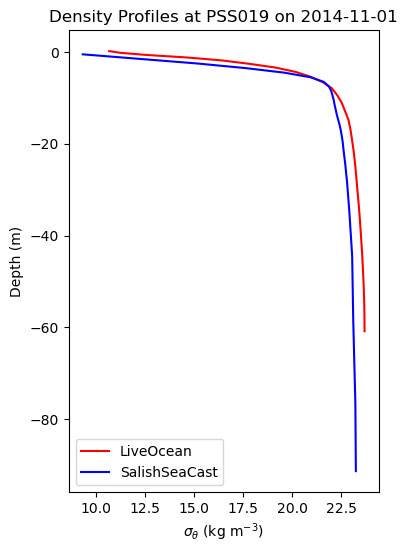

In [58]:
target = np.datetime64("2014-11-01")
itime = np.argmin(np.abs(ds_ssc["time_counter"].values - target))

plt.figure(figsize=(4,6))

plt.plot(sigma_theta_lo[itime,:], z_lo[itime,:],
         label='LiveOcean', color = 'red')

plt.plot(sigma_theta_ssc[itime,:], -z_ssc,
         label='SalishSeaCast', color = 'blue')

plt.xlabel(r'$\sigma_\theta$ (kg m$^{-3}$)')
plt.ylabel('Depth (m)')
plt.legend()
plt.title(f'Density Profiles at {station} on {target}')

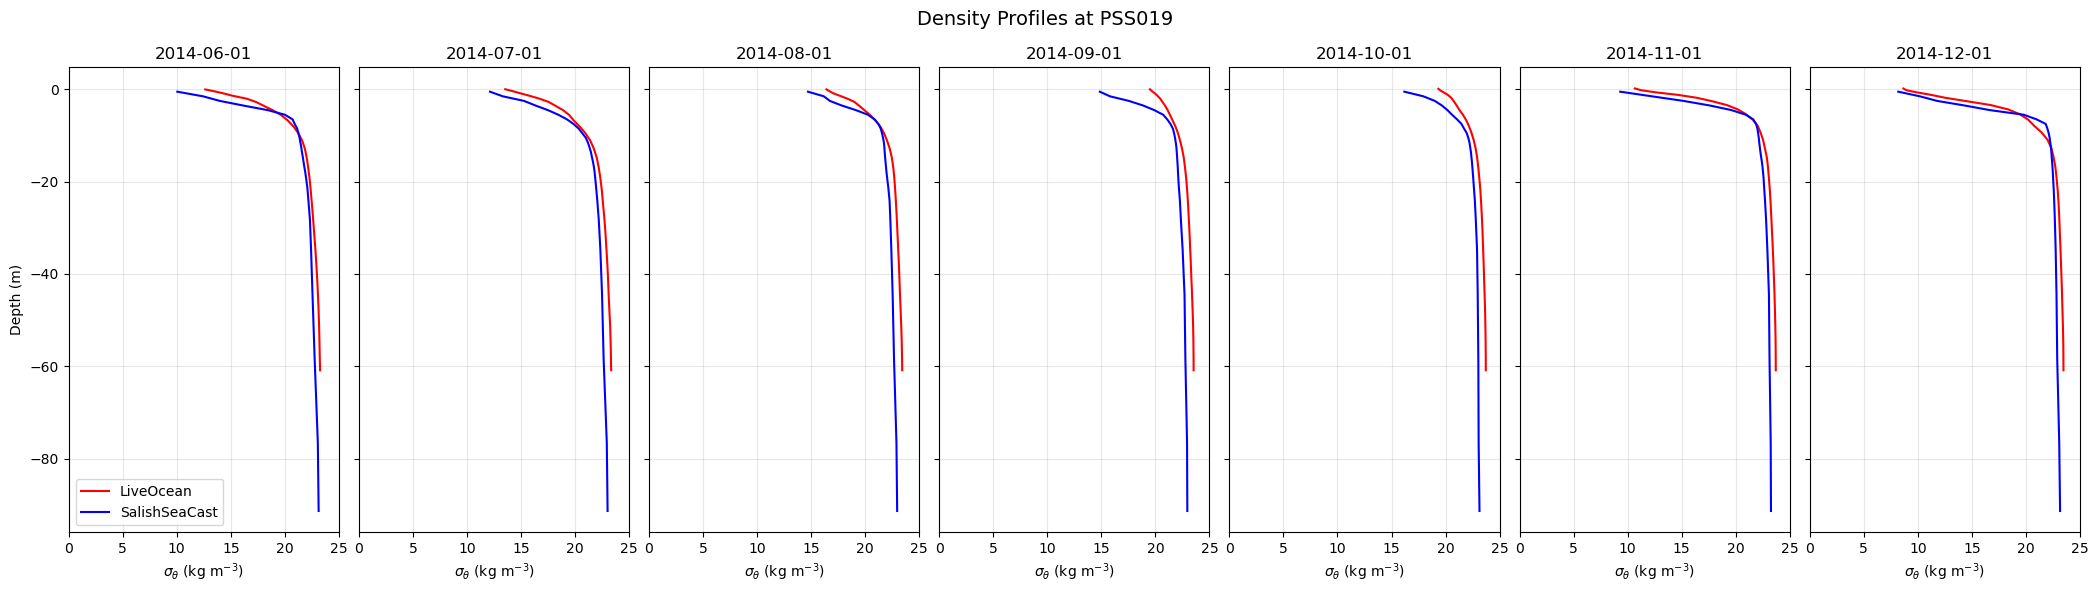

In [59]:
### DENSITY PROFILES FOR MULTIPLE DATES ###
# ------------------------------------------------------------
# Dates to plot
# ------------------------------------------------------------

targets = [
    np.datetime64("2014-06-01"),
    np.datetime64("2014-07-01"),
    np.datetime64("2014-08-01"),
    np.datetime64("2014-09-01"),
    np.datetime64("2014-10-01"),
    np.datetime64("2014-11-01"),
    np.datetime64("2014-12-01"),
]

# ------------------------------------------------------------
# Create subplots
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1, len(targets),
    figsize=(3 * len(targets), 6),
    sharey=True
)

# ------------------------------------------------------------
# Plot each date
# ------------------------------------------------------------

for ax, target in zip(axes, targets):

    # Find nearest SSC time
    itime = np.argmin(
        np.abs(ds_ssc["time_counter"].values - target)
    )

    ax.plot(
        sigma_theta_lo[itime, :],
        z_lo[itime, :],
        label="LiveOcean",
        color="red"
    )

    ax.plot(
        sigma_theta_ssc[itime, :],
        -z_ssc,
        label="SalishSeaCast",
        color="blue"
    )
    
    ax.set_xlim(0, 25)  # x-axis limits

    ax.set_xlabel(r'$\sigma_\theta$ (kg m$^{-3}$)')
    ax.set_title(str(target))

    ax.grid(True, alpha=0.3)

# ------------------------------------------------------------
# Labels and formatting
# ------------------------------------------------------------

axes[0].set_ylabel("Depth (m)")

# One legend for the entire figure
axes[0].legend()

fig.suptitle(
    f"Density Profiles at {station}",
    fontsize=14
)

plt.tight_layout()
plt.show()

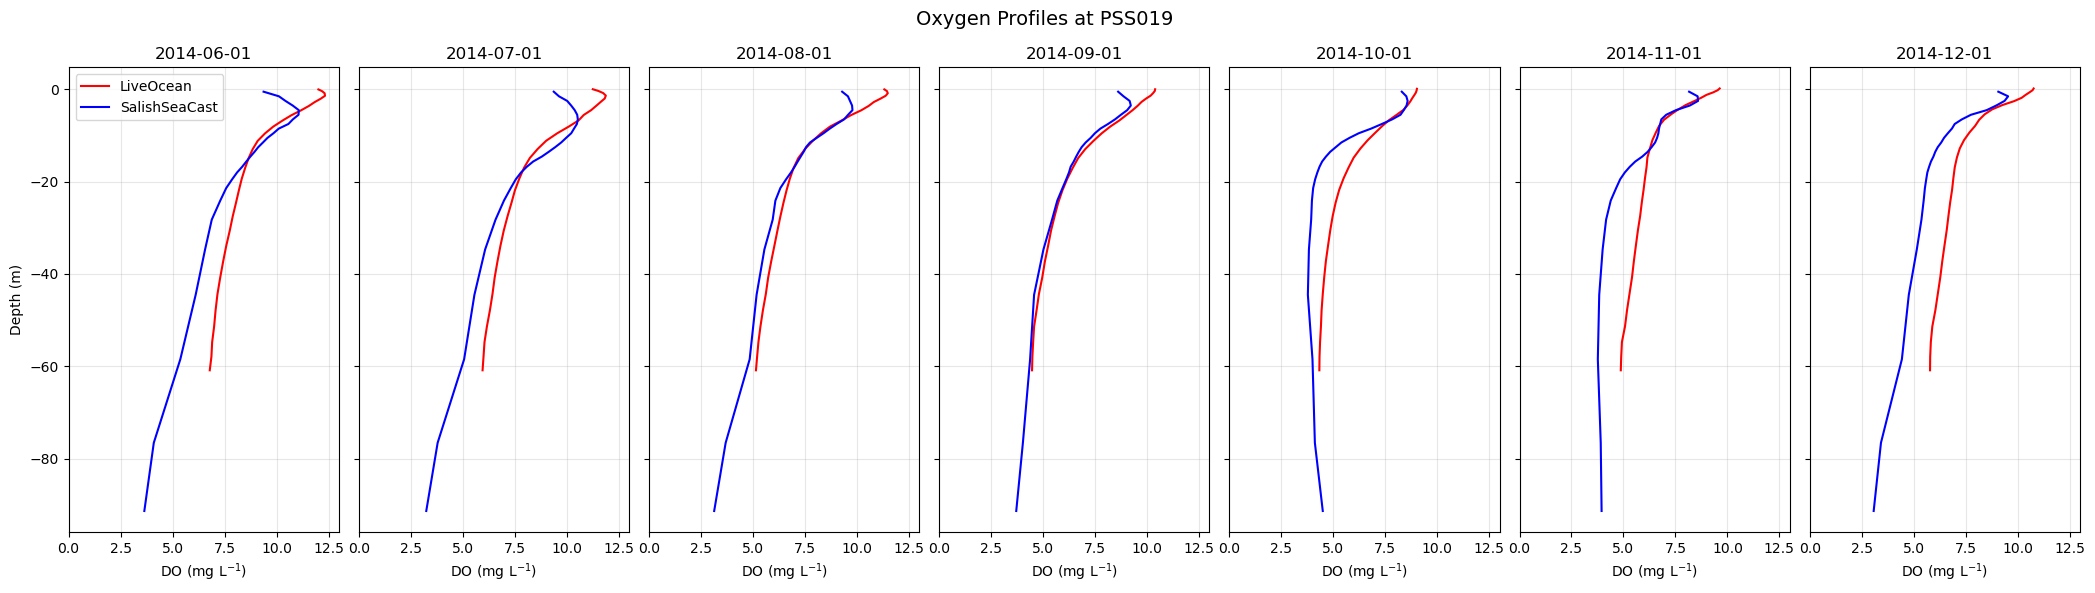

In [60]:
### OXYGEN PROFILES FOR MULTIPLE DATES ###

DO_lo = ds_lo['oxygen'].values * 0.032
DO_ssc = ds_ssc['dissolved_oxygen'].values * 0.032
DO_ssc = np.where(DO_ssc == 0, np.nan, DO_ssc)
# ------------------------------------------------------------
# Dates to plot
# ------------------------------------------------------------

targets = [
    np.datetime64("2014-06-01"),
    np.datetime64("2014-07-01"),
    np.datetime64("2014-08-01"),
    np.datetime64("2014-09-01"),
    np.datetime64("2014-10-01"),
    np.datetime64("2014-11-01"),
    np.datetime64("2014-12-01"),
]

# ------------------------------------------------------------
# Create subplots
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1, len(targets),
    figsize=(3 * len(targets), 6),
    sharey=True
)

# ------------------------------------------------------------
# Plot each date
# ------------------------------------------------------------

for ax, target in zip(axes, targets):

    # Find nearest SSC time
    itime = np.argmin(
        np.abs(ds_ssc["time_counter"].values - target)
    )

    ax.plot(
        DO_lo[itime, :],
        z_lo[itime, :],
        label="LiveOcean",
        color="red"
    )

    ax.plot(
        DO_ssc[itime, :],
        -z_ssc,
        label="SalishSeaCast",
        color="blue"
    )
    
    ax.set_xlim(0, 13)  # x-axis limits

    ax.set_xlabel(r'DO (mg L$^{-1}$)')
    ax.set_title(str(target))

    ax.grid(True, alpha=0.3)

# ------------------------------------------------------------
# Labels and formatting
# ------------------------------------------------------------

axes[0].set_ylabel("Depth (m)")

# One legend for the entire figure
axes[0].legend()

fig.suptitle(
    f"Oxygen Profiles at {station}",
    fontsize=14
)

plt.tight_layout()
plt.show()

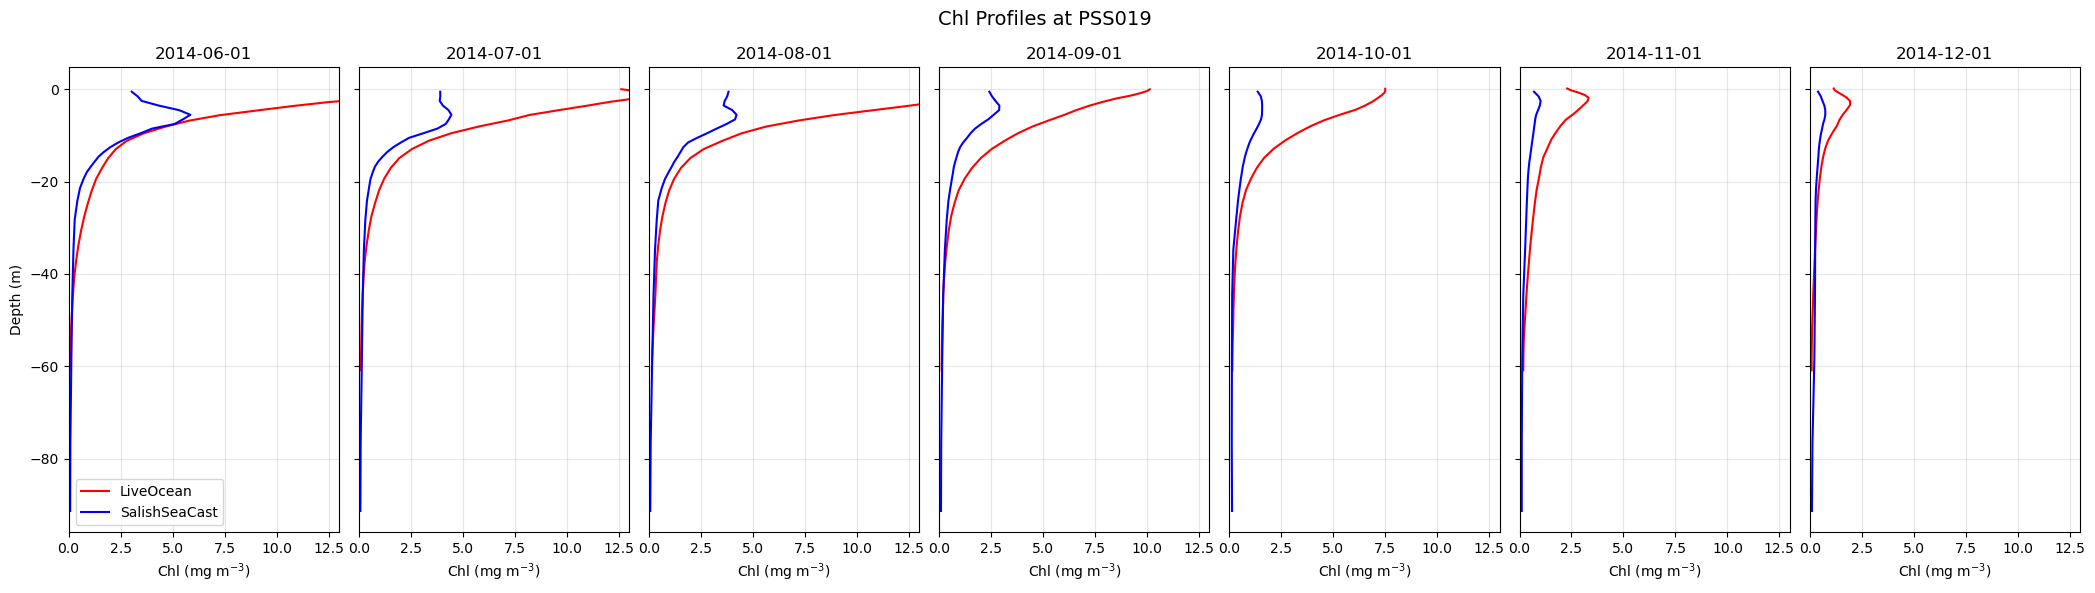

In [61]:
### CHL PROFILES FOR MULTIPLE DATES ###

chl_lo = ds_lo['phytoplankton'].values * 2.5
chl_ssc = (ds_ssc['diatoms'].values + ds_ssc['flagellates'].values) * 2
chl_ssc = np.where(chl_ssc == 0, np.nan, chl_ssc)

# ------------------------------------------------------------
# Dates to plot
# ------------------------------------------------------------

targets = [
    np.datetime64("2014-06-01"),
    np.datetime64("2014-07-01"),
    np.datetime64("2014-08-01"),
    np.datetime64("2014-09-01"),
    np.datetime64("2014-10-01"),
    np.datetime64("2014-11-01"),
    np.datetime64("2014-12-01"),
]

# ------------------------------------------------------------
# Create subplots
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1, len(targets),
    figsize=(3 * len(targets), 6),
    sharey=True
)

# ------------------------------------------------------------
# Plot each date
# ------------------------------------------------------------

for ax, target in zip(axes, targets):

    # Find nearest SSC time
    itime = np.argmin(
        np.abs(ds_ssc["time_counter"].values - target)
    )

    ax.plot(
        chl_lo[itime, :],
        z_lo[itime, :],
        label="LiveOcean",
        color="red"
    )

    ax.plot(
        chl_ssc[itime, :],
        -z_ssc,
        label="SalishSeaCast",
        color="blue"
    )
    
    ax.set_xlim(0, 13)  # x-axis limits

    ax.set_xlabel(r'Chl (mg m$^{-3}$)')
    ax.set_title(str(target))

    ax.grid(True, alpha=0.3)

# ------------------------------------------------------------
# Labels and formatting
# ------------------------------------------------------------

axes[0].set_ylabel("Depth (m)")

# One legend for the entire figure
axes[0].legend()

fig.suptitle(
    f"Chl Profiles at {station}",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [65]:
# ------------------------------------------------------------
# Choose actual observation dates at this station
# ------------------------------------------------------------

TIME_TOLERANCE = pd.Timedelta(hours=3)

obs_station = obs[obs["name"] == station].copy()
obs_station["time"] = pd.to_datetime(obs_station["time"])

# Keep observations with DO measurements
obs_station = obs_station.dropna(subset=["DO"])

# Choose approximately one observation date per season/month
target_months = [6, 7, 8, 9, 10, 11, 12]

targets = []

for month in target_months:

    obs_month = obs_station[
        obs_station["time"].dt.month == month
    ]

    if len(obs_month) == 0:
        continue

    # Group by calendar date
    obs_month["date"] = obs_month["time"].dt.normalize()

    dates = obs_month["date"].unique()

    # Choose date closest to middle of month
    target_date = pd.Timestamp(2014, month, 15)

    closest_date = min(
        dates,
        key=lambda d: abs(pd.Timestamp(d) - target_date)
    )

    targets.append(pd.Timestamp(closest_date))

print("Selected dates:")
for target in targets:
    print(target.strftime("%Y-%m-%d"))

Selected dates:
2014-06-23
2014-07-29
2014-08-18
2014-09-16
2014-11-18


/tmp/ipykernel_117733/2604615725.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obs_month["date"] = obs_month["time"].dt.normalize()
/tmp/ipykernel_117733/2604615725.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obs_month["date"] = obs_month["time"].dt.normalize()
/tmp/ipykernel_117733/2604615725.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:/

2014-06-23 number of observations: 4
2014-07-29 number of observations: 5
2014-08-18 number of observations: 6
2014-09-16 number of observations: 6
2014-11-18 number of observations: 1


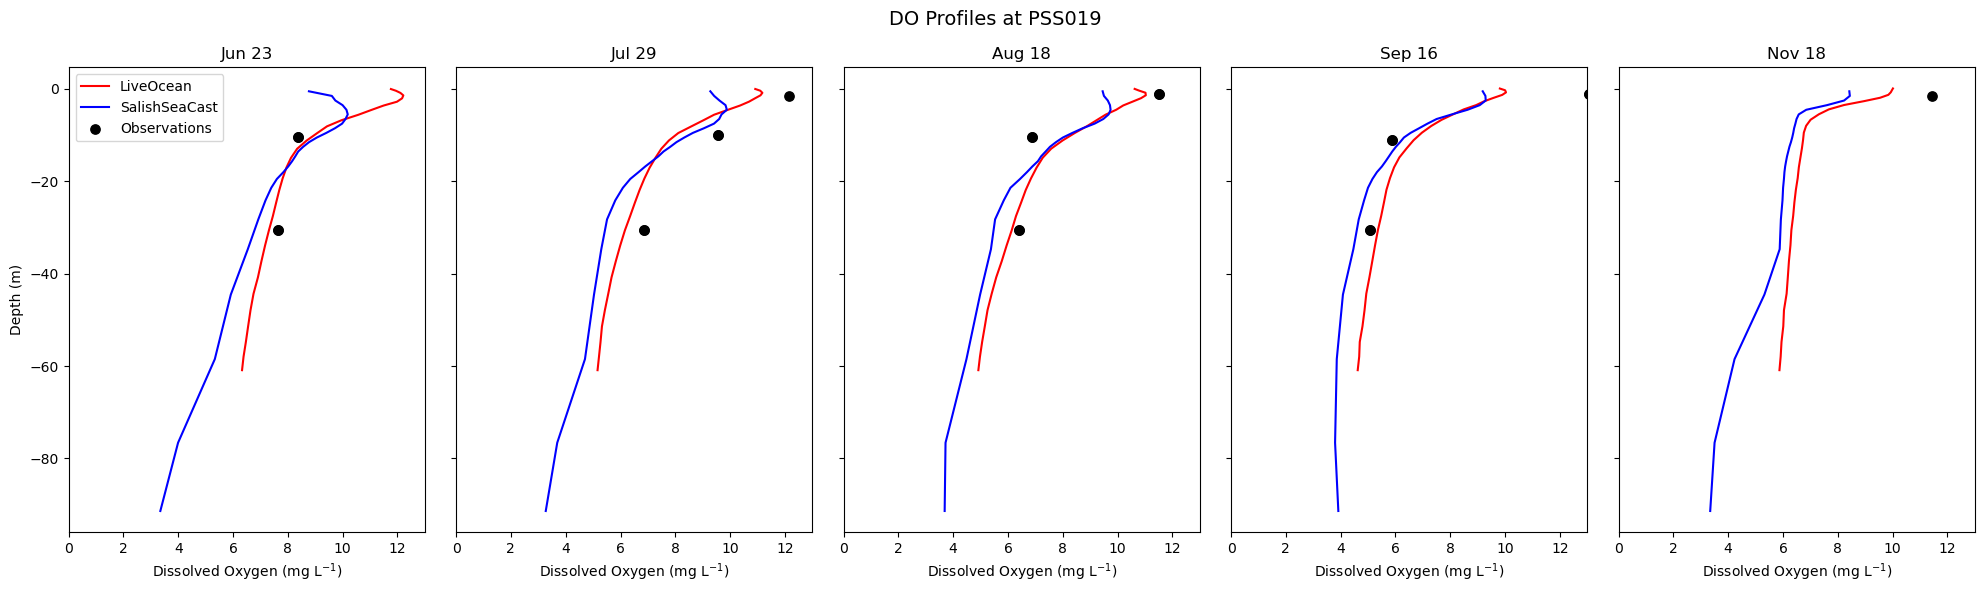

In [66]:
### DO WITH OBS ###
# ------------------------------------------------------------
# Plot profiles
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1, len(targets),
    figsize=(4 * len(targets), 6),
    sharey=True
)

if len(targets) == 1:
    axes = [axes]

for ax, target in zip(axes, targets):

    # --------------------------------------------------------
    # Find closest model time
    # --------------------------------------------------------

    itime = np.argmin(
        np.abs(
            ds_ssc["time_counter"].values -
            target.to_datetime64()
        )
    )

    # --------------------------------------------------------
    # Model profiles
    # --------------------------------------------------------

    ax.plot(
        DO_lo[itime, :],
        z_lo[itime, :],
        color="red",
        label="LiveOcean"
    )

    ax.plot(
        DO_ssc[itime, :],
        -z_ssc,
        color="blue",
        label="SalishSeaCast"
    )

    # --------------------------------------------------------
    # Observations from that calendar day
    # --------------------------------------------------------

    obs_date = obs_station[
        obs_station["time"].dt.normalize() == target
    ].copy()

    # Remove missing DO or depth
    obs_date = obs_date.dropna(subset=["DO", "z"])

    print(
        target.strftime("%Y-%m-%d"),
        "number of observations:",
        len(obs_date)
    )

    # --------------------------------------------------------
    # Plot observations
    # --------------------------------------------------------

    ax.scatter(
        obs_date["DO"] * 0.032,
        obs_date["z"],
        color="black",
        s=45,
        zorder=10,
        label="Observations"
    )

    ax.set_xlim(0, 13)
    ax.set_xlabel("Dissolved Oxygen (mg L$^{-1}$)")
    ax.set_title(target.strftime("%b %d"))

axes[0].set_ylabel("Depth (m)")

fig.suptitle(
    f"DO Profiles at {station}",
    fontsize=14
)

axes[0].legend()

plt.tight_layout()
plt.show()

2014-06-23 number of observations: 4
2014-07-29 number of observations: 5
2014-08-18 number of observations: 6
2014-09-16 number of observations: 6
2014-11-18 number of observations: 1


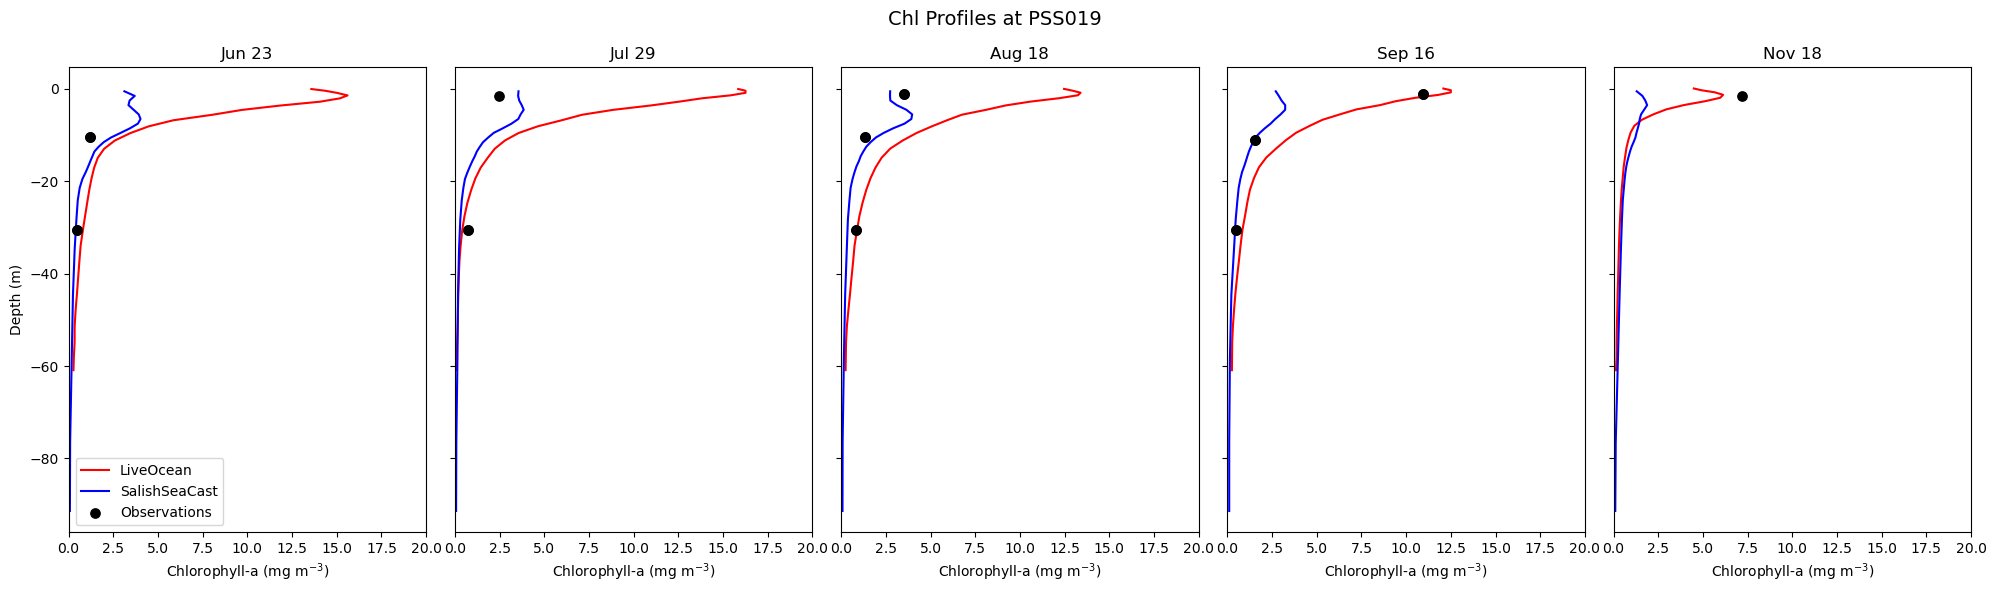

In [67]:
### CHL WITH OBS ###
# ------------------------------------------------------------
# Plot profiles
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1, len(targets),
    figsize=(4 * len(targets), 6),
    sharey=True
)

if len(targets) == 1:
    axes = [axes]

for ax, target in zip(axes, targets):

    # --------------------------------------------------------
    # Find closest model time
    # --------------------------------------------------------

    itime = np.argmin(
        np.abs(
            ds_ssc["time_counter"].values -
            target.to_datetime64()
        )
    )

    # --------------------------------------------------------
    # Model profiles
    # --------------------------------------------------------

    ax.plot(
        chl_lo[itime, :],
        z_lo[itime, :],
        color="red",
        label="LiveOcean"
    )

    ax.plot(
        chl_ssc[itime, :],
        -z_ssc,
        color="blue",
        label="SalishSeaCast"
    )

    # --------------------------------------------------------
    # Observations from that calendar day
    # --------------------------------------------------------

    obs_date = obs_station[
        obs_station["time"].dt.normalize() == target
    ].copy()

    # Remove missing Chl or depth
    obs_date = obs_date.dropna(subset=["Chl", "z"])

    print(
        target.strftime("%Y-%m-%d"),
        "number of observations:",
        len(obs_date)
    )

    # --------------------------------------------------------
    # Plot observations
    # --------------------------------------------------------

    ax.scatter(
        obs_date["Chl"],
        obs_date["z"],
        color="black",
        s=45,
        zorder=10,
        label="Observations"
    )

    ax.set_xlim(0, 20)
    ax.set_xlabel("Chlorophyll-a (mg m$^{-3}$)")
    ax.set_title(target.strftime("%b %d"))

axes[0].set_ylabel("Depth (m)")

fig.suptitle(
    f"Chl Profiles at {station}",
    fontsize=14
)

axes[0].legend()

plt.tight_layout()
plt.show()